# Chapter 10.3: Real-time Inference

## Learning Objectives

By the end of this notebook, you will be able to:

1. Implement **streaming feature computation** at serving time using real-time user signals
2. Analyze **real-time scoring vs pre-computation** trade-offs for different use cases
3. Understand **edge inference** concepts for on-device recommendation
4. Optimize **feature lookups** with embedding caching and Bloom filters
5. Implement **model hotswap** for near-real-time model updates without downtime
6. Design **shadow deployment** systems for safe model rollouts
7. Build a complete real-time scoring service with feature caching

## Prerequisites

- Chapter 10.1 (Serving Architecture)
- Chapter 10.2 (Model Optimization)
- Understanding of streaming data concepts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part10/chapter_10.3_realtime_inference.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part10/chapter_10.3_realtime_inference.ipynb)

In [1]:
import numpy as np
import time
import hashlib
import math
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Set
from collections import OrderedDict, deque, defaultdict
import matplotlib.pyplot as plt

np.random.seed(42)

print("All imports successful!")

All imports successful!


## 1. Streaming Features at Serving Time

Real-time recommendation requires **fresh features** that capture the user's latest behavior. There are three feature freshness tiers:

| Tier | Freshness | Example | Storage |
|------|-----------|---------|----------|
| Batch | Hours-days | User demographics, item metadata | Data warehouse |
| Near-real-time | Minutes | Session click count, category affinity | Streaming pipeline |
| Real-time | Seconds | Last clicked item, scroll depth | In-memory store |

The feature computation pipeline:

$$
\mathbf{f}_{\text{user}}(t) = [\mathbf{f}_{\text{batch}} \| \mathbf{f}_{\text{NRT}}(t) \| \mathbf{f}_{\text{RT}}(t)]
$$

where $\|$ denotes concatenation, and features at each tier have different update frequencies.

> **💡 Concept:** ByteDance's Monolith system (ICLR 2022) eliminates the batch-to-serving feature gap by computing features directly from the streaming training pipeline. This "real-time training" approach means the model always uses the freshest possible features.

In [2]:
# Simulate a real-time feature store

@dataclass
class UserEvent:
    user_id: str
    item_id: str
    event_type: str  # 'click', 'view', 'purchase'
    timestamp: float
    category: str


class RealTimeFeatureStore:
    """Computes and serves real-time user features from event streams."""

    def __init__(self, window_seconds: float = 300.0):
        self.window_seconds = window_seconds
        # Per-user event buffers
        self.user_events: Dict[str, deque] = defaultdict(deque)
        # Batch features (pre-computed, rarely change)
        self.batch_features: Dict[str, np.ndarray] = {}
        # Stats
        self.feature_compute_times = []

    def ingest_event(self, event: UserEvent):
        """Ingest a new user event into the streaming buffer."""
        self.user_events[event.user_id].append(event)
        # Prune old events outside the window
        while (len(self.user_events[event.user_id]) > 0 and
               event.timestamp - self.user_events[event.user_id][0].timestamp > self.window_seconds):
            self.user_events[event.user_id].popleft()

    def compute_realtime_features(self, user_id: str, current_time: float) -> np.ndarray:
        """Compute real-time features from the event stream."""
        start = time.perf_counter()

        events = list(self.user_events.get(user_id, []))
        # Filter to window
        events = [e for e in events if current_time - e.timestamp <= self.window_seconds]

        features = np.zeros(20, dtype=np.float32)

        if len(events) == 0:
            self.feature_compute_times.append((time.perf_counter() - start) * 1000)
            return features

        # Feature 0-2: Event counts by type
        for e in events:
            if e.event_type == 'click':
                features[0] += 1
            elif e.event_type == 'view':
                features[1] += 1
            elif e.event_type == 'purchase':
                features[2] += 1

        # Feature 3: Click-through rate in window
        if features[1] > 0:
            features[3] = features[0] / features[1]

        # Feature 4: Time since last event (seconds)
        features[4] = current_time - events[-1].timestamp

        # Feature 5: Event rate (events per minute)
        time_span = max(current_time - events[0].timestamp, 1.0)
        features[5] = len(events) / (time_span / 60.0)

        # Feature 6-10: Category distribution (top 5 categories)
        cat_counts = defaultdict(int)
        for e in events:
            cat_counts[e.category] += 1
        top_cats = sorted(cat_counts.items(), key=lambda x: -x[1])[:5]
        for i, (cat, count) in enumerate(top_cats):
            features[6 + i] = count / len(events)

        # Feature 11-15: Recency-weighted interaction features
        for i, e in enumerate(reversed(events)):
            if i >= 5:
                break
            decay = np.exp(-0.01 * (current_time - e.timestamp))
            features[11 + i] = decay

        # Feature 16-19: Session statistics
        features[16] = len(events)  # Session length
        features[17] = len(set(e.item_id for e in events))  # Unique items
        features[18] = len(cat_counts)  # Category diversity
        inter_event_times = [events[i+1].timestamp - events[i].timestamp
                             for i in range(len(events) - 1) if len(events) > 1]
        features[19] = np.mean(inter_event_times) if inter_event_times else 0

        elapsed = (time.perf_counter() - start) * 1000
        self.feature_compute_times.append(elapsed)
        return features


# Generate synthetic event stream
np.random.seed(42)
categories = ["electronics", "fashion", "food", "sports", "books",
              "music", "games", "home", "beauty", "toys"]
event_types = ["view", "click", "purchase"]
event_probs = [0.6, 0.3, 0.1]

feature_store = RealTimeFeatureStore(window_seconds=300)

# Simulate 5 minutes of events for 100 users
num_users = 100
current_time = 0.0

for _ in range(5000):
    current_time += np.random.exponential(0.06)  # ~17 events/sec
    user_id = f"user_{np.random.randint(num_users)}"
    event = UserEvent(
        user_id=user_id,
        item_id=f"item_{np.random.randint(1000)}",
        event_type=np.random.choice(event_types, p=event_probs),
        timestamp=current_time,
        category=np.random.choice(categories)
    )
    feature_store.ingest_event(event)

# Compute features for a sample of users
sample_features = {}
for i in range(10):
    uid = f"user_{i}"
    features = feature_store.compute_realtime_features(uid, current_time)
    sample_features[uid] = features
    if i < 3:
        print(f"{uid}: clicks={features[0]:.0f}, views={features[1]:.0f}, "
              f"CTR={features[3]:.2f}, events/min={features[5]:.1f}, "
              f"unique_items={features[17]:.0f}")

print(f"\nFeature compute time: "
      f"P50={np.percentile(feature_store.feature_compute_times, 50):.3f}ms, "
      f"P99={np.percentile(feature_store.feature_compute_times, 99):.3f}ms")

user_0: clicks=14, views=28, CTR=0.50, events/min=8.9, unique_items=43
user_1: clicks=10, views=27, CTR=0.37, events/min=8.0, unique_items=40
user_2: clicks=16, views=31, CTR=0.52, events/min=10.2, unique_items=50

Feature compute time: P50=0.220ms, P99=0.272ms


## 2. Real-time Scoring vs Pre-computation

The fundamental trade-off in serving:

| Approach | Latency | Freshness | Cost | Best For |
|----------|---------|-----------|------|----------|
| Pre-computed | <1ms (cache lookup) | Stale (hours) | High storage | Homepage, email |
| Real-time scoring | 10-100ms | Fresh | High compute | Feed, search |
| Hybrid | 5-50ms | Semi-fresh | Balanced | Most production systems |

The hybrid approach: pre-compute candidates + real-time re-ranking:

$$
\text{score}(u, i, t) = \underbrace{f_{\text{static}}(u, i)}_{\text{pre-computed}} + \underbrace{g_{\text{dynamic}}(u, i, t)}_{\text{real-time}}
$$

where $f_{\text{static}}$ captures long-term preferences and $g_{\text{dynamic}}$ captures recency, context, and freshness.

> **🔑 Pro Tip:** LinkedIn uses a hybrid approach for feed ranking: pre-computed candidate retrieval + real-time ranking with fresh engagement features. This achieves <100ms latency while incorporating features that are <1 minute old.

In [3]:
# Compare pre-computed vs real-time scoring

class PrecomputedScorer:
    """Serves pre-computed scores from a cache."""

    def __init__(self, num_users: int, num_items: int):
        # Pre-compute top-K items per user
        self.top_items: Dict[str, List[Tuple[str, float]]] = {}
        for u in range(num_users):
            scores = np.random.random(num_items)
            top_k_idx = np.argsort(-scores)[:100]
            self.top_items[f"user_{u}"] = [
                (f"item_{idx}", scores[idx]) for idx in top_k_idx
            ]
        self.compute_time = 0.0  # Pre-computation done offline

    def score(self, user_id: str) -> Tuple[List[Tuple[str, float]], float]:
        start = time.perf_counter()
        result = self.top_items.get(user_id, [])
        latency = (time.perf_counter() - start) * 1000
        return result, latency


class RealTimeScorer:
    """Scores items in real-time using fresh features."""

    def __init__(self, num_items: int, feature_dim: int = 64):
        self.item_embeddings = np.random.randn(num_items, feature_dim).astype(np.float32)
        self.item_embeddings /= np.linalg.norm(self.item_embeddings, axis=1, keepdims=True)

    def score(self, user_embedding: np.ndarray, candidate_ids: List[int]) -> Tuple[List[Tuple[str, float]], float]:
        start = time.perf_counter()
        # Get candidate embeddings
        candidates = self.item_embeddings[candidate_ids]
        # Dot product scoring
        scores = candidates @ user_embedding
        # Sort by score
        ranked_idx = np.argsort(-scores)[:100]
        result = [(f"item_{candidate_ids[i]}", float(scores[i])) for i in ranked_idx]
        latency = (time.perf_counter() - start) * 1000
        return result, latency


class HybridScorer:
    """Pre-computed retrieval + real-time re-ranking."""

    def __init__(self, precomputed: PrecomputedScorer, realtime: RealTimeScorer):
        self.precomputed = precomputed
        self.realtime = realtime

    def score(self, user_id: str, user_embedding: np.ndarray,
              context_boost: Dict[str, float] = None) -> Tuple[List[Tuple[str, float]], float]:
        start = time.perf_counter()

        # Get pre-computed candidates
        precomp_results, _ = self.precomputed.score(user_id)

        # Re-rank with real-time features
        reranked = []
        for item_id, static_score in precomp_results:
            # Add real-time context boost
            dynamic_score = 0.0
            if context_boost and item_id in context_boost:
                dynamic_score = context_boost[item_id]
            # Add freshness decay
            freshness = np.random.exponential(0.1)  # Simulate freshness feature
            combined_score = 0.7 * static_score + 0.2 * dynamic_score + 0.1 * freshness
            reranked.append((item_id, combined_score))

        reranked.sort(key=lambda x: -x[1])
        latency = (time.perf_counter() - start) * 1000
        return reranked, latency


# Benchmark all three approaches
np.random.seed(42)
num_users, num_items = 100, 10000

precomputed = PrecomputedScorer(num_users, num_items)
realtime = RealTimeScorer(num_items)
hybrid = HybridScorer(precomputed, realtime)

n_requests = 1000
precomp_latencies, rt_latencies, hybrid_latencies = [], [], []

for _ in range(n_requests):
    uid = f"user_{np.random.randint(num_users)}"
    user_emb = np.random.randn(64).astype(np.float32)
    user_emb /= np.linalg.norm(user_emb)

    _, lat = precomputed.score(uid)
    precomp_latencies.append(lat)

    candidates = np.random.choice(num_items, 500, replace=False).tolist()
    _, lat = realtime.score(user_emb, candidates)
    rt_latencies.append(lat)

    _, lat = hybrid.score(uid, user_emb)
    hybrid_latencies.append(lat)

print(f"{'Approach':<20} | {'P50 (ms)':>10} | {'P99 (ms)':>10}")
print("-" * 45)
for name, lats in [("Pre-computed", precomp_latencies),
                    ("Real-time", rt_latencies),
                    ("Hybrid", hybrid_latencies)]:
    print(f"{name:<20} | {np.percentile(lats, 50):>10.3f} | {np.percentile(lats, 99):>10.3f}")

Approach             |   P50 (ms) |   P99 (ms)
---------------------------------------------
Pre-computed         |      0.001 |      0.002
Real-time            |      0.194 |      0.278
Hybrid               |      0.178 |      0.254


## 3. Feature Lookup Optimization: Bloom Filters

**Bloom filters** are space-efficient probabilistic data structures used to test set membership. In rec systems, they help:

- Check if a user has seen an item (deduplication) without expensive DB lookups
- Filter candidate items before expensive scoring
- Gate feature lookups (skip lookup if item definitely not in feature store)

A Bloom filter uses $k$ hash functions and a bit array of size $m$:

$$
P(\text{false positive}) \approx \left(1 - e^{-kn/m}\right)^k
$$

where $n$ is the number of elements inserted. Optimal $k$ for minimum false positive rate:

$$
k_{\text{opt}} = \frac{m}{n} \ln 2
$$

> **⚠️ Common Pitfall:** Bloom filters have NO false negatives -- if the filter says an item is NOT in the set, it's guaranteed to be absent. But false positives mean some items will be unnecessarily looked up. Size the filter appropriately (8-10 bits per element for <1% FPR).

In [4]:
# Implement a Bloom Filter for item deduplication

class BloomFilter:
    """Space-efficient probabilistic set membership test."""

    def __init__(self, expected_elements: int, false_positive_rate: float = 0.01):
        # Calculate optimal size and number of hash functions
        self.m = self._optimal_size(expected_elements, false_positive_rate)
        self.k = self._optimal_hashes(self.m, expected_elements)
        self.bit_array = np.zeros(self.m, dtype=np.bool_)
        self.num_elements = 0

    @staticmethod
    def _optimal_size(n: int, p: float) -> int:
        """Optimal bit array size."""
        m = -n * math.log(p) / (math.log(2) ** 2)
        return int(math.ceil(m))

    @staticmethod
    def _optimal_hashes(m: int, n: int) -> int:
        """Optimal number of hash functions."""
        k = (m / n) * math.log(2)
        return max(1, int(math.ceil(k)))

    def _hash_values(self, item: str) -> List[int]:
        """Generate k hash values using double hashing."""
        h1 = int(hashlib.md5(item.encode()).hexdigest(), 16)
        h2 = int(hashlib.sha1(item.encode()).hexdigest(), 16)
        return [(h1 + i * h2) % self.m for i in range(self.k)]

    def add(self, item: str):
        """Add an item to the filter."""
        for idx in self._hash_values(item):
            self.bit_array[idx] = True
        self.num_elements += 1

    def might_contain(self, item: str) -> bool:
        """Check if item might be in the set (no false negatives)."""
        return all(self.bit_array[idx] for idx in self._hash_values(item))

    @property
    def memory_bytes(self) -> int:
        return self.m // 8

    @property
    def theoretical_fpr(self) -> float:
        return (1 - math.exp(-self.k * self.num_elements / self.m)) ** self.k


# Demonstrate Bloom filter for deduplication
np.random.seed(42)

# Simulate: user has seen 10000 items, we want to filter them out cheaply
n_seen = 10000
seen_items = [f"item_{i}" for i in range(n_seen)]
unseen_items = [f"item_{i}" for i in range(n_seen, n_seen + 10000)]

bloom = BloomFilter(expected_elements=n_seen, false_positive_rate=0.01)
for item in seen_items:
    bloom.add(item)

# Test accuracy
true_positives = sum(bloom.might_contain(item) for item in seen_items)
false_positives = sum(bloom.might_contain(item) for item in unseen_items)

print(f"Bloom Filter Configuration:")
print(f"  Bit array size: {bloom.m:,} bits ({bloom.memory_bytes:,} bytes)")
print(f"  Hash functions: {bloom.k}")
print(f"  Elements: {bloom.num_elements:,}")
print(f"\nAccuracy:")
print(f"  True positives: {true_positives}/{n_seen} ({true_positives/n_seen:.2%})")
print(f"  False positives: {false_positives}/{len(unseen_items)} ({false_positives/len(unseen_items):.2%})")
print(f"  Theoretical FPR: {bloom.theoretical_fpr:.4%}")
print(f"\nMemory: {bloom.memory_bytes / 1024:.1f} KB vs "
      f"{n_seen * 20 / 1024:.1f} KB (hash set estimate)")
print(f"Memory savings: {(1 - bloom.memory_bytes / (n_seen * 20)) * 100:.1f}%")

Bloom Filter Configuration:
  Bit array size: 95,851 bits (11,981 bytes)
  Hash functions: 7
  Elements: 10,000

Accuracy:
  True positives: 10000/10000 (100.00%)
  False positives: 95/10000 (0.95%)
  Theoretical FPR: 1.0039%

Memory: 11.7 KB vs 195.3 KB (hash set estimate)
Memory savings: 94.0%


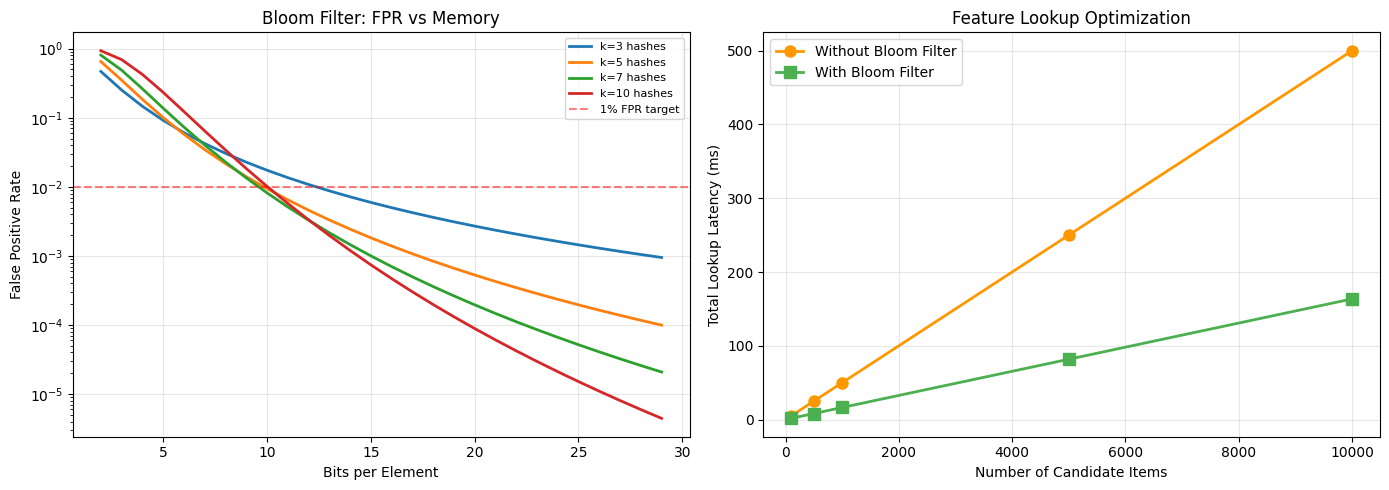

In [5]:
# Visualize Bloom filter FPR vs memory and demonstrate feature lookup optimization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: FPR vs bits per element
bits_per_element = np.arange(2, 30)
for k in [3, 5, 7, 10]:
    fprs = [(1 - np.exp(-k / bpe)) ** k for bpe in bits_per_element]
    axes[0].semilogy(bits_per_element, fprs, linewidth=2, label=f'k={k} hashes')

axes[0].set_xlabel("Bits per Element")
axes[0].set_ylabel("False Positive Rate")
axes[0].set_title("Bloom Filter: FPR vs Memory")
axes[0].axhline(y=0.01, color='red', linestyle='--', alpha=0.5, label='1% FPR target')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: Feature lookup latency with and without Bloom filter
# Simulate: for each candidate item, check if feature exists in store
n_candidates = np.array([100, 500, 1000, 5000, 10000])
store_hit_rate = 0.3  # 30% of items have features in store

# Without Bloom: lookup every item (expensive)
lookup_cost_ms = 0.05  # 50 microseconds per lookup
no_bloom_latency = n_candidates * lookup_cost_ms

# With Bloom: only lookup items that pass the filter
bloom_check_cost_ms = 0.001  # 1 microsecond per check
fpr = 0.01
bloom_latency = (n_candidates * bloom_check_cost_ms +
                 n_candidates * (store_hit_rate + (1 - store_hit_rate) * fpr) * lookup_cost_ms)

axes[1].plot(n_candidates, no_bloom_latency, 'o-', linewidth=2, markersize=8,
             color='#FF9800', label='Without Bloom Filter')
axes[1].plot(n_candidates, bloom_latency, 's-', linewidth=2, markersize=8,
             color='#4CAF50', label='With Bloom Filter')
axes[1].set_xlabel("Number of Candidate Items")
axes[1].set_ylabel("Total Lookup Latency (ms)")
axes[1].set_title("Feature Lookup Optimization")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Model Hotswap and Shadow Deployment

Updating models in production without downtime requires **model hotswap**:

1. **Load new model** into memory alongside the old model
2. **Warm up** the new model (populate caches, JIT compile)
3. **Atomic swap**: switch the serving pointer from old to new model
4. **Drain old model**: wait for in-flight requests to complete, then unload

**Shadow deployment** runs the new model in parallel without affecting production:

$$
\text{Response} = f_{\text{production}}(x) \quad \text{(served to user)}
$$
$$
\text{Shadow} = f_{\text{candidate}}(x) \quad \text{(logged for analysis)}
$$

This enables:
- **Performance validation**: Compare latency, memory, errors
- **Quality validation**: Compare predictions offline
- **Gradual rollout**: 0% → shadow → 1% → 5% → 50% → 100%

> **💡 Concept:** Meta deploys hundreds of model updates per day across their recommendation systems. Each update goes through shadow mode, canary (1%), ramped rollout, and full deployment -- all automated.

In [6]:
# Simulate model hotswap and shadow deployment

class ModelVersion:
    """Represents a deployed model version."""

    def __init__(self, version: str, quality: float, latency_ms: float):
        self.version = version
        self.quality = quality  # Simulated AUC
        self.latency_ms = latency_ms
        self.is_warm = False
        self.request_count = 0

    def warmup(self):
        """Simulate model warmup (JIT compilation, cache population)."""
        self.is_warm = True

    def predict(self) -> Tuple[float, float]:
        """Return (prediction_quality, latency)."""
        self.request_count += 1
        # Cold model is slower
        latency_factor = 1.0 if self.is_warm else 3.0
        latency = self.latency_ms * latency_factor * np.random.lognormal(0, 0.2)
        quality = self.quality + np.random.normal(0, 0.01)
        return quality, latency


class ModelServer:
    """Serves models with hotswap and shadow deployment support."""

    def __init__(self):
        self.production_model: Optional[ModelVersion] = None
        self.shadow_model: Optional[ModelVersion] = None
        self.rollout_percentage: float = 0.0
        self.history = []

    def deploy_production(self, model: ModelVersion):
        model.warmup()
        self.production_model = model

    def deploy_shadow(self, model: ModelVersion):
        model.warmup()
        self.shadow_model = model

    def start_rollout(self, percentage: float):
        self.rollout_percentage = percentage

    def promote_shadow(self):
        """Promote shadow model to production."""
        if self.shadow_model:
            self.production_model = self.shadow_model
            self.shadow_model = None
            self.rollout_percentage = 0.0

    def serve(self, request_time: float) -> Dict:
        """Serve a request, potentially using shadow model."""
        result = {"time": request_time}

        # Decide which model to use for serving
        use_shadow = (self.shadow_model is not None and
                      np.random.random() < self.rollout_percentage)

        if use_shadow:
            quality, latency = self.shadow_model.predict()
            result["served_by"] = self.shadow_model.version
        else:
            quality, latency = self.production_model.predict()
            result["served_by"] = self.production_model.version

        result["quality"] = quality
        result["latency"] = latency

        # Shadow mode: also score with shadow model (logged, not served)
        if self.shadow_model and not use_shadow:
            shadow_q, shadow_l = self.shadow_model.predict()
            result["shadow_quality"] = shadow_q
            result["shadow_latency"] = shadow_l

        self.history.append(result)
        return result


# Simulate a model deployment lifecycle
np.random.seed(42)
server = ModelServer()

# Phase 1: Production model v1
v1 = ModelVersion("v1", quality=0.75, latency_ms=15)
server.deploy_production(v1)

for t in range(500):
    server.serve(t)

# Phase 2: Deploy v2 in shadow mode
v2 = ModelVersion("v2", quality=0.78, latency_ms=18)  # Better quality, slightly slower
server.deploy_shadow(v2)

for t in range(500, 1000):
    server.serve(t)

# Phase 3: Start rolling out v2 (5%)
server.start_rollout(0.05)
for t in range(1000, 1500):
    server.serve(t)

# Phase 4: Increase rollout to 50%
server.start_rollout(0.50)
for t in range(1500, 2000):
    server.serve(t)

# Phase 5: Full promotion
server.promote_shadow()
for t in range(2000, 2500):
    server.serve(t)

# Analyze
phases = [(0, 500, "v1 only"), (500, 1000, "v2 shadow"),
          (1000, 1500, "5% rollout"), (1500, 2000, "50% rollout"),
          (2000, 2500, "v2 promoted")]

print(f"{'Phase':<15} | {'Avg Quality':>12} | {'P50 Latency':>12} | {'P99 Latency':>12}")
print("-" * 60)
for start, end, name in phases:
    phase_data = [h for h in server.history if start <= h["time"] < end]
    qualities = [h["quality"] for h in phase_data]
    latencies = [h["latency"] for h in phase_data]
    print(f"{name:<15} | {np.mean(qualities):>12.4f} | {np.percentile(latencies, 50):>10.1f}ms | "
          f"{np.percentile(latencies, 99):>10.1f}ms")

Phase           |  Avg Quality |  P50 Latency |  P99 Latency
------------------------------------------------------------
v1 only         |       0.7504 |       15.1ms |       23.8ms
v2 shadow       |       0.7507 |       15.2ms |       22.8ms
5% rollout      |       0.7509 |       15.0ms |       24.7ms
50% rollout     |       0.7654 |       16.7ms |       29.0ms
v2 promoted     |       0.7808 |       17.8ms |       30.2ms


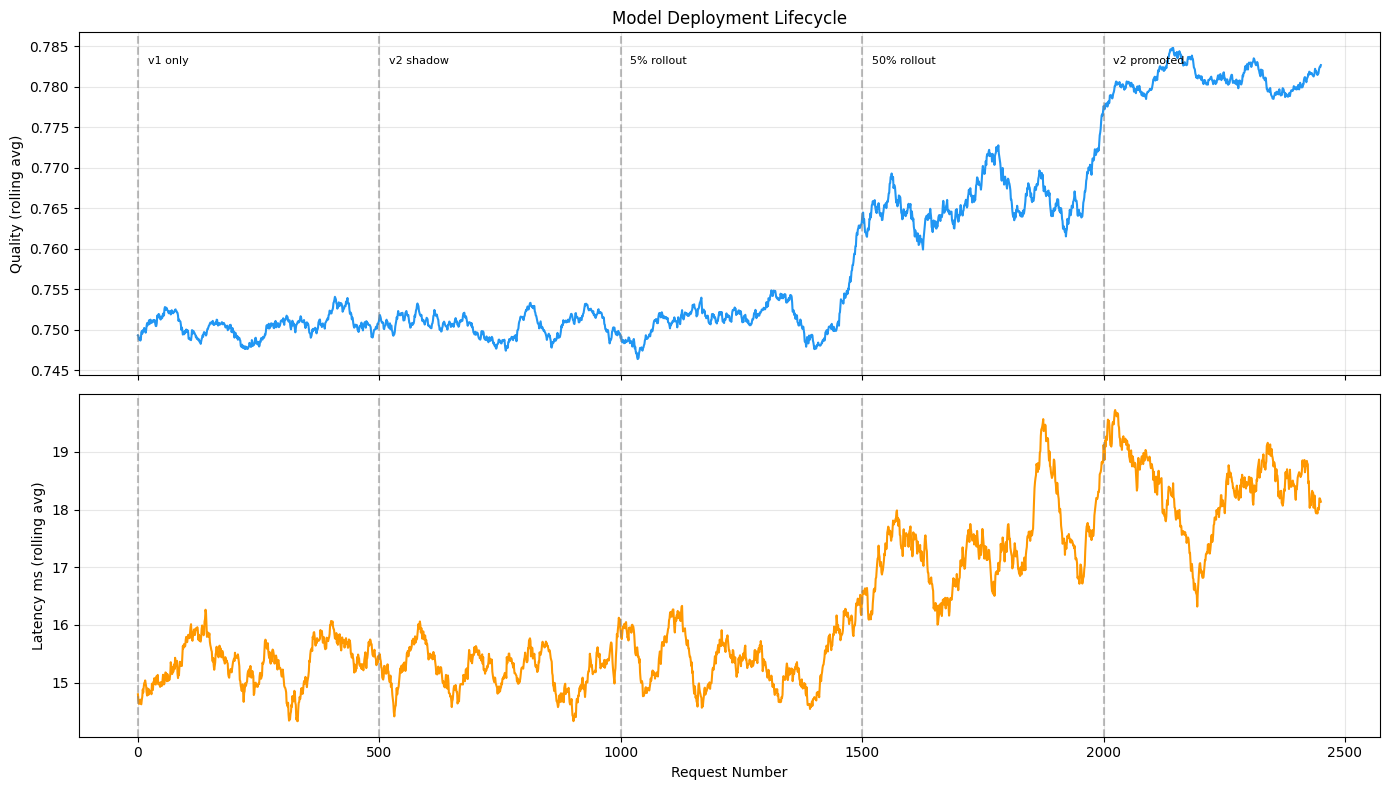

In [7]:
# Visualize the deployment lifecycle
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

times = [h["time"] for h in server.history]
qualities = [h["quality"] for h in server.history]
latencies = [h["latency"] for h in server.history]

# Rolling averages
window = 50
rolling_quality = np.convolve(qualities, np.ones(window)/window, mode='valid')
rolling_latency = np.convolve(latencies, np.ones(window)/window, mode='valid')
rolling_times = times[:len(rolling_quality)]

# Quality plot
axes[0].plot(rolling_times, rolling_quality, linewidth=1.5, color='#2196F3')
for start, end, name in phases:
    axes[0].axvline(x=start, color='gray', linestyle='--', alpha=0.5)
    axes[0].text(start + 20, max(rolling_quality) - 0.002, name,
                 fontsize=8, rotation=0)

axes[0].set_ylabel("Quality (rolling avg)")
axes[0].set_title("Model Deployment Lifecycle")
axes[0].grid(alpha=0.3)

# Latency plot
axes[1].plot(rolling_times, rolling_latency, linewidth=1.5, color='#FF9800')
for start, end, name in phases:
    axes[1].axvline(x=start, color='gray', linestyle='--', alpha=0.5)

axes[1].set_xlabel("Request Number")
axes[1].set_ylabel("Latency ms (rolling avg)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Edge Inference for Recommendations

**On-device recommendation** runs models directly on the user's device (phone, browser) for:

- **Zero network latency**: Results in <5ms
- **Privacy**: User data never leaves the device
- **Offline capability**: Works without network

Constraints for edge models:

| Resource | Mobile Budget | Server Budget |
|----------|--------------|---------------|
| Model size | <10 MB | GBs |
| RAM | <50 MB | GBs |
| Compute | CPU only | GPU clusters |
| Latency | <10ms | <100ms |

Common approach: **on-device re-ranking** of server-provided candidates.

> **🔑 Pro Tip:** Apple's on-device recommendation system uses a combination of CoreML models and on-device user profiles. The server sends ~100 candidate items periodically, and the on-device model re-ranks them in real-time based on local context (time of day, recent interactions, battery level).

In [8]:
# Simulate edge vs server inference

@dataclass
class InferenceConfig:
    name: str
    model_size_mb: float
    inference_ms: float  # Per-batch inference
    network_ms: float    # Network latency (0 for edge)
    quality: float       # Relative quality (0-1)


configs = [
    InferenceConfig("Server (full model)", 500, 20, 50, 0.95),
    InferenceConfig("Server (distilled)", 50, 8, 50, 0.90),
    InferenceConfig("Edge (full re-rank)", 5, 8, 0, 0.82),
    InferenceConfig("Edge (light re-rank)", 1, 2, 0, 0.75),
    InferenceConfig("Hybrid (server + edge)", 5, 5, 30, 0.92),
]

# Simulate latencies with network variability
np.random.seed(42)
n_requests = 5000

results = {}
for config in configs:
    latencies = []
    for _ in range(n_requests):
        # Inference latency (log-normal)
        inf_lat = np.random.lognormal(np.log(config.inference_ms), 0.3)
        # Network latency (log-normal, more variable)
        net_lat = np.random.lognormal(np.log(max(config.network_ms, 0.1)), 0.5) if config.network_ms > 0 else 0
        latencies.append(inf_lat + net_lat)
    results[config.name] = {
        "latencies": latencies,
        "quality": config.quality,
        "model_size_mb": config.model_size_mb,
    }

print(f"{'Config':<25} | {'P50':>8} | {'P99':>8} | {'Quality':>8} | {'Size (MB)':>10}")
print("-" * 70)
for name, r in results.items():
    print(f"{name:<25} | {np.percentile(r['latencies'], 50):>6.1f}ms | "
          f"{np.percentile(r['latencies'], 99):>6.1f}ms | "
          f"{r['quality']:>8.2f} | {r['model_size_mb']:>10.1f}")

Config                    |      P50 |      P99 |  Quality |  Size (MB)
----------------------------------------------------------------------
Server (full model)       |   71.3ms |  182.9ms |     0.95 |      500.0
Server (distilled)        |   58.9ms |  167.2ms |     0.90 |       50.0
Edge (full re-rank)       |    8.0ms |   15.5ms |     0.82 |        5.0
Edge (light re-rank)      |    2.0ms |    4.0ms |     0.75 |        1.0
Hybrid (server + edge)    |   35.1ms |   99.6ms |     0.92 |        5.0


## Exercises

### 🏋️ Exercise 1: Build a Real-time Scoring Service with Feature Caching

Build a complete real-time scoring service that:
1. Maintains a streaming feature store
2. Uses a Bloom filter for item deduplication
3. Implements embedding caching for fast feature lookup
4. Tracks latency at each stage

In [9]:
# 🏋️ Exercise 1: Real-time scoring service

class RealTimeScoringService:
    """Complete real-time scoring service."""

    def __init__(self, num_items: int = 10000):
        # TODO: Initialize components
        # 1. Real-time feature store
        # 2. Bloom filter for seen items
        # 3. Embedding cache (LRU)
        # 4. Scoring model (simple dot product)
        pass

    def ingest_event(self, user_id: str, item_id: str, event_type: str,
                     timestamp: float):
        # TODO: Process incoming event
        # 1. Update feature store
        # 2. Add item to user's Bloom filter
        pass

    def score(self, user_id: str, candidate_item_ids: List[str],
              timestamp: float) -> Dict:
        # TODO: Score candidates
        # 1. Filter seen items using Bloom filter
        # 2. Look up user features (with caching)
        # 3. Look up item embeddings (with caching)
        # 4. Score remaining candidates
        # 5. Return top-K with latency breakdown
        pass


# TODO: Simulate 10 minutes of traffic and analyze:
# - Feature freshness (how old are features at scoring time?)
# - Deduplication effectiveness (what % of items filtered by Bloom?)
# - Cache hit rates
# - End-to-end latency distribution

### 🏋️ Exercise 2: Shadow Deployment Analyzer

Implement a shadow deployment analysis system that compares production and shadow model predictions.

In [10]:
# 🏋️ Exercise 2: Shadow deployment analysis

class ShadowAnalyzer:
    """Analyze shadow deployment results."""

    def __init__(self):
        # TODO: Initialize metrics tracking
        pass

    def compare(self, production_scores: np.ndarray,
                shadow_scores: np.ndarray) -> Dict:
        # TODO: Compute comparison metrics
        # 1. Rank correlation (Spearman)
        # 2. Top-K overlap at K=10, 20, 50
        # 3. Score distribution comparison
        # 4. Latency comparison
        pass

    def should_promote(self) -> Tuple[bool, str]:
        # TODO: Decision logic for promotion
        # Criteria: quality improvement > threshold, latency within budget,
        #           no error rate increase
        pass


# TODO: Simulate 3 scenarios:
# 1. Shadow model is clearly better -> promote
# 2. Shadow model is similar -> need more data
# 3. Shadow model has latency regression -> reject

### 🏋️ Exercise 3: Adaptive Feature Freshness

Implement a system that dynamically adjusts feature freshness based on user activity level.

In [11]:
# 🏋️ Exercise 3: Adaptive feature freshness

# TODO: Design a system where:
# - Highly active users (>10 events/min) get real-time features
# - Moderately active users (1-10 events/min) get near-real-time features  
# - Inactive users get batch features
# This saves compute by not computing expensive real-time features for cold users

# Simulate and measure:
# 1. Compute savings vs all-real-time
# 2. Quality impact (measure recommendation quality per user tier)

## Summary

Key takeaways:

1. **Streaming features** at three freshness tiers (batch, NRT, real-time) provide the right trade-off between freshness and cost
2. **Pre-computation vs real-time scoring** is not binary -- hybrid approaches (pre-computed candidates + real-time re-ranking) work best
3. **Bloom filters** save significant memory and latency for deduplication and feature lookup gating
4. **Model hotswap** with shadow deployment enables safe, zero-downtime model updates
5. **Edge inference** provides zero-latency recommendations for re-ranking on-device

### References

- Zhao et al., "Monolith: Real Time Recommendation System With Collisionless Embedding Table" (2022, ByteDance, ICLR)
- Hermann et al., "Real-time Machine Learning at Uber" (2020)
- LinkedIn Engineering, "Near Real-time Features for Near Real-time Personalization" (2022)
- Bloom, "Space/Time Trade-offs in Hash Coding with Allowable Errors" (1970)